In [1]:
from core import altopt, plot_altopt
from core import DataContext, ParameterContext
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from core import get_final_interpolator

In [ ]:
DATA_DIR = r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_7"
DATASET3 = DataContext(
    sim_time = os.path.join(DATA_DIR, "t_array.csv"),
    sim_freq = os.path.join(DATA_DIR, "delz_MHz.csv"),
    sim_by = os.path.join(DATA_DIR, "dely_MHz.csv"),
    sim_intensities = sorted([
        os.path.join(DATA_DIR, f) for f in os.listdir(DATA_DIR) if f.startswith("transH_t_vs_Bz_alpha2500_delx_0.01_dely_") and f.endswith(".csv")
    ], key=lambda x: float(x.split("_dely_")[1].split(".csv")[0])),
    exp_time = r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\t_array_.csv",
    exp_freq_axis = r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\Y_MHz.csv",
    exp_data = r"DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\Bx_V_Readout.csv",
    save_path = r"Results\Dataset_7\21_Mar\Test_1_Dataset_7_from_25_microseconds_0.2_step_Adaptive_Bias_Selection",
    interpolator=r"DataFiles_to_Dinesh_Pranav\Data_files\Simulation\Dataset_7\gpu_sim_interpolator_new_normalisation_linear_0.3_threshold.npz",
    Aligned = False,
    sim_pulse_thresh=0.3,
    exp_pulse_thresh=0.3
)
DEFAULT_ALTOPT_PARAMS = ParameterContext(
    num_iter=15,
    curr_time = 25.0,
    max_time = 70.0,
    tol_bz=1e-20,
    tol_by=1e-20,
    t_step = 0.2,
    fixed_by_estimate=0.0,
    B_unk_bound_transverse_upper=0.4,
    fixed_bz_estimate=0.0,
    print_plot = False,
    Est_First_Z= False
)

In [ ]:
Test = f"Dataset_7_Starting with {DEFAULT_ALTOPT_PARAMS.curr_time} us_T Step {DEFAULT_ALTOPT_PARAMS.t_step} us_zero initial estimate"
DEFAULT_ALTOPT_PARAMS.Test = Test

...Starting Adaptive Experiment for Y Estimation...
Loading Experiment from DataFiles_to_Dinesh_Pranav\Data_files\Experiment\13_02_2026_CW_data\Bx_V_Readout.csv...
  > Exp Start: 0.0122s
0.10348916053771973 was the time taken to load exp data.
...Building Final Interpolator...
Time taken to load Interpolator: 1.1740081310272217
0.1408405303955078 was the time taken to compute the Transverse Likelihood calculation. | 
 T=25.2 | BiasZ=0.000 | Est By=0.07660 | Std=0.0237| Res=1.0e-04KL Calculation Time: 0.12179446220397949 0.004553079605102539 was the time taken to compute the Transverse Likelihood calculation. | 
 T=25.4 | BiasZ=0.214 | Est By=0.07730 | Std=0.0031| Res=1.0e-04KL Calculation Time: 0.08602523803710938 0.004297733306884766 was the time taken to compute the Transverse Likelihood calculation. |   [ZOOM] Triggered! Mass concentrated in 357 points.| New Res: 9.09090909090909e-05 | Idx_01: 633 |Idx_99: 990 | new_b_grid_gpu[idx_01]: 0.06330000000000001 | new_b_grid_gpu[idx_99]: 0

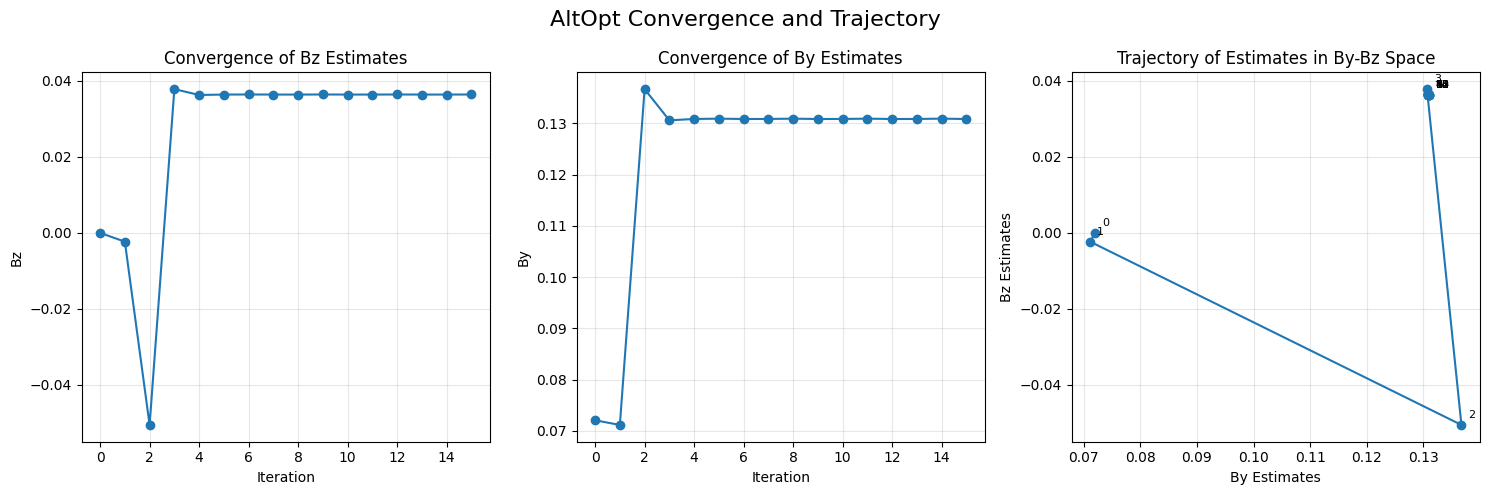

[0.0, np.float64(-0.0023057851239669607), np.float64(-0.050534702050736284), np.float64(0.037833554104683954), np.float64(0.03629067983443995), np.float64(0.036401959092124715), np.float64(0.036421792823588435), np.float64(0.036403170420917653), np.float64(0.036401959092124715), np.float64(0.036421792823588435), np.float64(0.036403170420917653), np.float64(0.036401959092124715), np.float64(0.036421792823588435), np.float64(0.036403170420917653), np.float64(0.036401959092124715), np.float64(0.036421792823588435)] [np.float64(0.07205885526944882), np.float64(0.07115117706926263), np.float64(0.13670000000000002), np.float64(0.13061301140632472), np.float64(0.1308729022596456), np.float64(0.1309364592582474), np.float64(0.13086803401068323), np.float64(0.13087837014926385), np.float64(0.1309364592582474), np.float64(0.13086803401068323), np.float64(0.13087837014926385), np.float64(0.1309364592582474), np.float64(0.13086803401068323), np.float64(0.13087837014926385), np.float64(0.1309364592

In [5]:
results = altopt(DATASET3, DEFAULT_ALTOPT_PARAMS)
plot_altopt(DATASET3, *results)
print(*results)

New Plotting 

1. I need to create a concatenated array containing all the means and std devs, and also need to give it a savepath, which is fine

In [ ]:
directory = r"Results\Dataset_7\21_Mar\Test_1_Dataset_7_from_25_microseconds_0.2_step_Adaptive_Bias_Selection\Test_2026_03_21"
result_longitudinal_list = sorted([
        os.path.join(directory, f) for f in os.listdir(directory) if f.startswith(r"longitudinal_estimation_results_Dataset_7_Starting with 25.0 us_T Step 0.2 us_zero initial estimate_20260321") and f.endswith(r".npz")
    ], key=lambda x: float(x.split(r"_20260321_")[1].split(r".npz")[0]))
result_transverse_list = sorted([
        os.path.join(directory, f) for f in os.listdir(directory) if f.startswith(r"transverse_field_estimation_results_Dataset_7_Starting with 25.0 us_T Step 0.2 us_zero initial estimate_20260321") and f.endswith(r".npz")
    ], key=lambda x: float(x.split(r"_20260321_")[1].split(r".npz")[0]))

longitudinal_estimation_results = [np.load(f) for f in result_longitudinal_list]
transverse_field_estimation_results = [np.load(f) for f in result_transverse_list]
print(len(longitudinal_estimation_results), len(transverse_field_estimation_results))

bz_full_traj = []
bz_final_estimate = []
by_full_traj = []
by_final_estimate = []
bz_full_std = []
by_full_std = []
iters_per_block = 0
save_path = directory
for i in range(len(longitudinal_estimation_results)):
    if i==0:
        iters_per_block = longitudinal_estimation_results[i]["est"].shape[0]
        print(f"Iters per block: {iters_per_block}")
    bz_full_std += list(longitudinal_estimation_results[i]["stddev"])
    bz_full_traj += list(longitudinal_estimation_results[i]["est"])
    bz_final_estimate.append(longitudinal_estimation_results[i]["est"][-1])
    by_full_std += list(transverse_field_estimation_results[i]["stddev"])
    by_full_traj += list(transverse_field_estimation_results[i]["est"])
    if i!=0 or i == len(longitudinal_estimation_results) - 1:
        by_final_estimate.append(transverse_field_estimation_results[i]["est"][-1])

        #Since, sigma is not a good measure for confidence interval, let us use interval estimation of 90% probability for each posterior, the posterior is a numpy array 
        bz_posterior = np.array(longitudinal_estimation_results[i]["posteriors"])
        by_posterior = np.array(transverse_field_estimation_results[i]["posteriors"])
        bz_grid = np.array(longitudinal_estimation_results[i]["bgrids"])
        by_grid = np.array(transverse_field_estimation_results[i]["bgrids"])

print(len(bz_full_traj), len(by_full_traj), len(bz_full_std), len(by_full_std))
bz_full_traj, bz_full_std, by_full_traj, by_full_std = np.array(bz_full_traj), np.array(bz_full_std), np.array(by_full_traj), np.array(by_full_std)   
    

15 17
Iters per block: 225
3375 3150 3375 3150


In [11]:
def plot_intra_iteration_convergence(bz_full_traj, bz_full_std, bz_final_estimate, by_full_traj, by_full_std, by_final_estimate, iters_per_block, save_path=None):
    """
    Plots the continuous, intra-iteration evolution of the Bayesian estimates.
    
    Parameters:
    - bz_full_traj, bz_full_std: 1D numpy arrays of length (N_total_steps)
    - by_full_traj, by_full_std: 1D numpy arrays of length (N_total_steps)
    - iters_per_block: Integer (e.g., if you run 100 KL steps per alternating iteration)
    """
    bz_full_traj, bz_full_std, by_full_traj, by_full_std, bz_final_estimate, by_final_estimate = np.array(bz_full_traj)/0.7, np.array(bz_full_std)/0.7, np.array(by_full_traj)/0.7, np.array(by_full_std)/0.7, np.array(bz_final_estimate)/0.7, np.array(by_final_estimate)/0.7 
    # Create an artificial x-axis where 1 "unit" is a full Alternating Optimization block
    n_total_steps = len(bz_full_traj)
    x_axis = np.arange(n_total_steps) / iters_per_block
    num_blocks = int(np.ceil(n_total_steps / iters_per_block))
    
    plt.rcParams.update({'font.family': 'serif', 'font.size': 10})
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, gridspec_kw={'hspace': 0.1})

    # Plot Bz
    ax1.plot(x_axis, bz_full_traj, color='#1f77b4', linewidth=1.5, label='Intra-iteration MAP')
    ax1.plot(range(1,num_blocks+1), bz_final_estimate, '--', color= "#487494",marker = 'o', markersize=4, label='Final Estimate')
    ax1.fill_between(x_axis, bz_full_traj - 5*bz_full_std, bz_full_traj + 5*bz_full_std, color='#1f77b4', alpha=0.3, label=r'$\pm 5\sigma$')
    # ax1.fill_between(x_axis, bz_full_traj - 3*bz_full_std, bz_full_traj + 3*bz_full_std, color='#1f77b4', alpha=0.1, label=r'$\pm 3\sigma$')
    ax1.set_ylabel(r'$B_z$ Estimate (Gauss)')
    ax1.grid(True, linestyle=':', alpha=0.5)
    ax1.set_ylim(-1/0.7, 1/0.7)
    # ax1.autoscale(enable=True, axis='y', tight=True)
    ax1.legend(loc='upper right', framealpha=0.9, ncol=2)

    # Plot By
    ax2.plot(x_axis, by_full_traj, color='#d62728', linewidth=1.5, label='Intra-iteration MAP')
    ax2.plot(range(1,num_blocks+1), by_final_estimate, '--', color= "#487494",marker = 'o', markersize=4, label='Final Estimate')
    ax2.fill_between(x_axis, by_full_traj - 5*by_full_std, by_full_traj + 5*by_full_std, color='#d62728', alpha=0.3, label=r'$\pm 5\sigma$')
    # ax2.fill_between(x_axis, by_full_traj - 3*by_full_std, by_full_traj + 3*by_full_std, color='#d62728', alpha=0.1, label=r'$\pm 3\sigma$')
    ax2.set_ylabel(r'$B_y$ Estimate (Gauss)')
    ax2.set_xlabel('Alternating Optimization Iteration')
    ax2.grid(True, linestyle=':', alpha=0.5)
    ax2.set_ylim(0, 0.4/0.7)
    # ax2.autoscale(enable=True, axis='y', tight=True)
    ax2.legend(loc='upper right', framealpha=0.9, ncol=2)

    # Formatting visual dividers
    num_blocks = int(np.ceil(n_total_steps / iters_per_block))
    for i in range(num_blocks + 1):
        ax1.axvline(i, color='black', linestyle='-')
        ax2.axvline(i, color='black', linestyle='-')
        
        '''# Optional: Shade the background to show which variable is actively updating
        if i < num_blocks:
            if i % 2 == 0:
                ax1.axvspan(i, i+1, color='#1f77b4', alpha=0.05) # Bz Active
            else:
                ax2.axvspan(i, i+1, color='#d62728', alpha=0.05) # By Active'''

    ax2.set_xlim(0, num_blocks)
    ax2.set_xticks(np.arange(num_blocks + 1))
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

ValueError: x and y must have same first dimension, but have shapes (3375,) and (3150,)

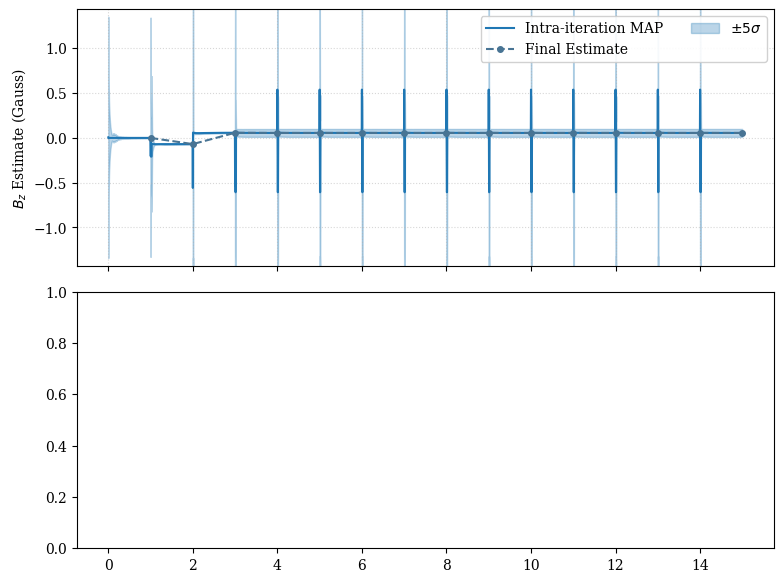

In [12]:
plot_intra_iteration_convergence(bz_full_traj, bz_full_std, bz_final_estimate,by_full_traj, by_full_std, by_final_estimate, iters_per_block, save_path=os.path.join(save_path, "intra_iteration_convergence.png"))